# ExpectedPoints HW_2

In [36]:
import os
import tabulate
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nflreadpy import load_pbp
import statsmodels.formula.api as smf
import pyarrow
import sportsdataverse as sdv
import polars as pl
from great_tables import GT, md
from adjustText import adjust_text


In [30]:
# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

In [37]:
# ---------------------------------------------------------
# 1. Load play-by-play data (2022–2025)
# ---------------------------------------------------------
seasons = [2022, 2023, 2024, 2025]

pbp = sdv.cfb.load_cfb_pbp(seasons=seasons, return_as_pandas=False)
schedule = sdv.cfb.load_cfb_schedule(seasons=seasons, return_as_pandas=False)

print("PBP rows:", pbp.shape)
print("Schedule rows:", schedule.shape)

PBP rows: (632080, 477)
Schedule rows: (15079, 41)


In [40]:
# ---------------------------------------------------------
# Filter to FBS v FBS
# ---------------------------------------------------------
schedule_fbs = schedule.filter(
    pl.col("fbs_game") == True
)

print("FBS vs FBS games:", schedule_fbs.shape)

# Keep only PBP from FBS vs FBS games
pbp_fbs = pbp.join(
    schedule_fbs.select("game_id"),
    on="game_id",
    how="inner"
)

print("FBS PBP rows:", pbp_fbs.shape)

FBS vs FBS games: (3175, 41)
FBS PBP rows: (541577, 477)


In [42]:
def process_next_score_data(df):
    # Base filtering
    filtered = df.filter(
        (pl.col('season_type') == 'REG') &
        (pl.col('ep').is_not_null()) &
        (pl.col('posteam').is_not_null()) &
        (~pl.col('play_type').is_in(['extra_point', 'two_point_attempt']))
    ).clone()

    # Calculate scores for each event type
    # Touchdowns
    filtered = filtered.with_columns(
        pl.when((pl.col('touchdown') == 1) & (pl.col('td_team') == pl.col('home_team')))
        .then(pl.lit(7.0))
        .when((pl.col('touchdown') == 1) & (pl.col('td_team') == pl.col('away_team')))
        .then(pl.lit(-7.0))
        .otherwise(pl.lit(None, dtype=pl.Float64)) # Explicitly use None for non-scoring TD plays
        .alias('td_score')
    )
    # Field Goals
    filtered = filtered.with_columns(
        pl.when((pl.col('field_goal_result') == 'made') & (pl.col('posteam') == pl.col('home_team')))
        .then(pl.lit(3.0))
        .when((pl.col('field_goal_result') == 'made') & (pl.col('posteam') == pl.col('away_team')))
        .then(pl.lit(-3.0))
        .otherwise(pl.lit(None, dtype=pl.Float64)) # Explicitly use None for non-scoring FG plays
        .alias('fg_score')
    )
    # Safeties
    filtered = filtered.with_columns(
        pl.when((pl.col('safety') == 1) & (pl.col('defteam') == pl.col('home_team')))
        .then(pl.lit(2.0))
        .when((pl.col('safety') == 1) & (pl.col('defteam') == pl.col('away_team')))
        .then(pl.lit(-2.0))
        .otherwise(pl.lit(None, dtype=pl.Float64)) # Explicitly use None for non-scoring Safety plays
        .alias('safety_score')
    )

    # Coalesce all scoring events into a single 'home_scoring_event' column
    # The first non-null value among td_score, fg_score, safety_score is taken.
    # If no score, it remains null.
    filtered = filtered.with_columns(
        pl.coalesce(['td_score', 'fg_score', 'safety_score']).alias('home_scoring_event')
    )

    # Drop intermediate columns
    filtered = filtered.drop(['td_score', 'fg_score', 'safety_score'])

    filtered = filtered.with_columns(
        pl.col('home_scoring_event')
        .fill_null(strategy='backward')
        .over(['game_id', 'game_half'])
    )

    # Step C: Fill remaining missing with 0
    filtered = filtered.with_columns(pl.col('home_scoring_event').fill_null(0))

    # Step D: Convert to possession team perspective
    filtered = filtered.with_columns(
        pl.when(pl.col('posteam') == pl.col('home_team'))
        .then(pl.col('home_scoring_event'))
        .otherwise(-pl.col('home_scoring_event'))
        .alias('pts_next_score')
    )
    # Ensure pts_next_score has no NaNs. Explicitly add this after calculation.
    filtered = filtered.with_columns(pl.col('pts_next_score').fill_null(0).alias('pts_next_score'))

    # Apply garbage time filter
    filtered = filtered.filter(
        (pl.col('wp').is_not_null()) &
        (pl.col('wp') >= 0.05) &
        (pl.col('wp') <= 0.95)
    ).clone() # Use .clone() for Polars instead of .copy() for sub-DataFrame operations

    return filtered


In [50]:
# ---------------------------------------------------------
# Create Expected Points dataset
# ---------------------------------------------------------
filtered = pbp_fbs.filter(
    pl.col("EP_start").is_not_null()
).clone()

# ---------------------------------------------------------
# Identify the next scoring event
# ---------------------------------------------------------
filtered = filtered.with_columns(
    pl.when(pl.col("scoring_play") == True)
    .then(pl.col("pos_score_pts").cast(pl.Float64))
    .otherwise(None)
    .alias("score_event")
)

filtered = filtered.with_columns(
    pl.col("score_event")
    .fill_null(strategy="backward")
    .over(["game_id", "half"])
    .alias("pts_next_score")
)

filtered = filtered.with_columns(
    pl.col("pts_next_score").fill_null(0)
)

print("Processed FBS rows:", filtered.shape)


Processed FBS rows: (541577, 479)


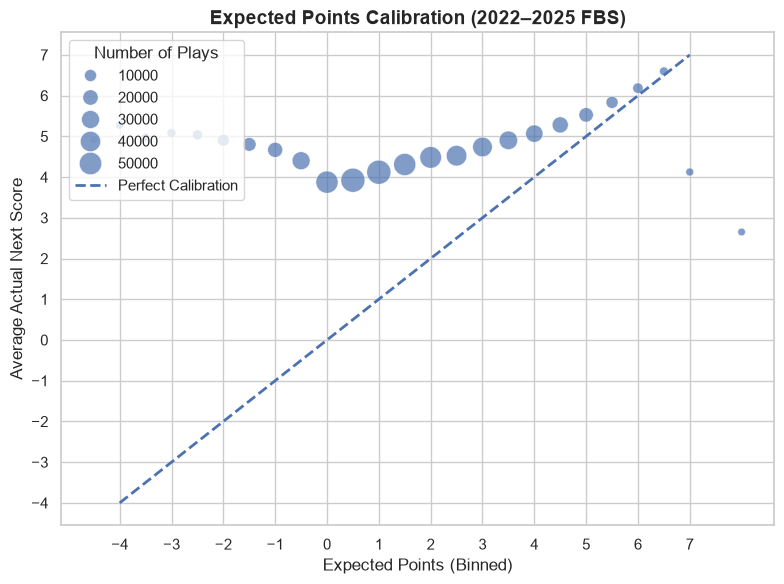

In [52]:
def plot_calibration(df, bin_width=0.5, min_plays=50, title_suffix="2022–2025 FBS"):
    df_copy = df.to_pandas().copy()

    df_copy["ep_bin"] = (
        df_copy["EP_start"] / bin_width
    ).round() * bin_width

    cal_data = df_copy.groupby("ep_bin").agg(
        actual_pts=("pts_next_score", "mean"),
        plays=("pts_next_score", "count")
    ).reset_index()

    cal_data = cal_data[cal_data["plays"] >= min_plays]

    fig, ax = plt.subplots(figsize=(8, 6))

    sns.scatterplot(
        data=cal_data,
        x="ep_bin",
        y="actual_pts",
        size="plays",
        sizes=(30, 300),
        alpha=0.7,
        ax=ax
    )

    ax.plot(
        [-4, 7],
        [-4, 7],
        linestyle="--",
        linewidth=2,
        label="Perfect Calibration"
    )

    ax.set_xticks(range(-4, 8))
    ax.set_yticks(range(-4, 8))
    ax.set_title(
        f"Expected Points Calibration ({title_suffix})",
        fontweight="bold",
        fontsize=14
    )
    ax.set_xlabel("Expected Points (Binned)")
    ax.set_ylabel("Average Actual Next Score")
    ax.legend(title="Number of Plays", loc="upper left")

    plt.tight_layout()
    plt.show()

plot_calibration(filtered)

In [54]:
# ---------------------------------------------------------
# Load NFL play-by-play data (2022–2025)
# ---------------------------------------------------------
nfl_pbp = load_pbp([2022, 2023, 2024, 2025])

print("NFL PBP rows:", nfl_pbp.shape)

NFL PBP rows: (197362, 372)


In [55]:
# ---------------------------------------------------------
# Process NFL data
# ---------------------------------------------------------
pbp_filtered = process_next_score_data(nfl_pbp)

print("Processed NFL rows:", pbp_filtered.shape)

Processed NFL rows: (144368, 374)


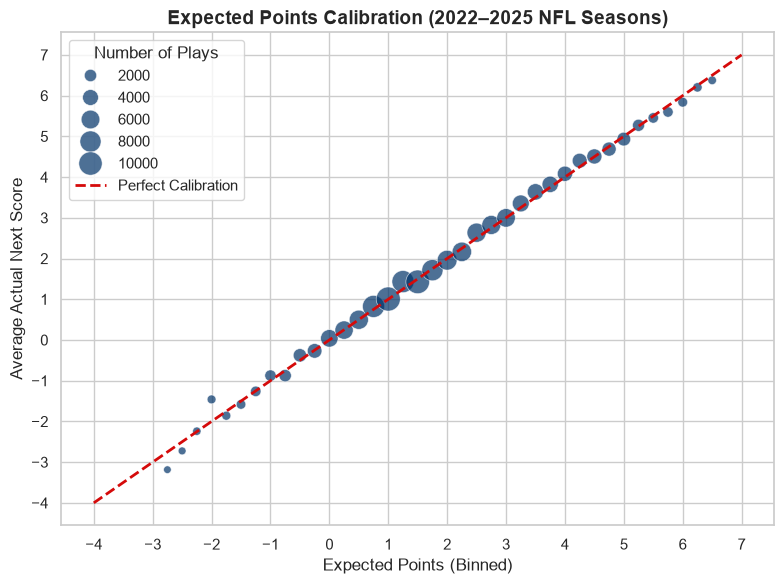

In [56]:
def plot_calibration(df, bin_width=0.25, min_plays=50, title_suffix="2024 NFL Season"):
    # Use .clone() for Polars DataFrame copy and .with_columns for new column creation
    df_plot = df.clone().with_columns(
        ((pl.col('ep') / bin_width).round() * bin_width).alias('ep_bin')
    )

    # Use Polars group_by and aggregation functions
    cal_data = df_plot.group_by('ep_bin').agg(
        pl.col('pts_next_score').mean().alias('actual_pts'),
        pl.col('pts_next_score').count().alias('plays')
    ).sort('ep_bin') # Sort by ep_bin for consistent plotting

    cal_data = cal_data.filter(pl.col('plays') >= min_plays)

    # Convert to pandas for seaborn plotting
    cal_data_pd = cal_data.to_pandas()

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=cal_data_pd, x='ep_bin', y='actual_pts', size='plays',
        sizes=(30, 300), color='#013369', alpha=0.7, ax=ax
    )
    ax.plot([-4, 7], [-4, 7], linestyle='--', color='#D50A0A', linewidth=2, label='Perfect Calibration')

    ax.set_xticks(range(-4, 8))
    ax.set_yticks(range(-4, 8))
    ax.set_title(f"Expected Points Calibration ({title_suffix})", fontweight='bold', fontsize=14)
    ax.set_xlabel("Expected Points (Binned)")
    ax.set_ylabel("Average Actual Next Score")
    ax.legend(title="Number of Plays", loc="upper left")
    plt.tight_layout()
    plt.show()

plot_calibration(
    pbp_filtered,
    title_suffix="2022–2025 NFL Seasons"
)

QUESTION 1: Explain in a paragraph the differences between the NFL model and the FBS-only model.

ANSWER: Looking at both the NFL and College Football models, the NFL data provides far more stability and reliability than the FBS model. In the NFL calibration scatterplot, the average actual next score values align tightly with the expected points estimates, indicating predictable patterns and very few extreme outliers. In contrast, the FBS model shows much wider dispersion around the calibration line. College football introduces greater variability due to mismatches in schedule strength and uneven team quality, with larger talent gaps, which create extreme outliers and may weaken the alignment with the expected points model. As a result, the NFL model is more consistent, while the FBS model reflects the inherent volatility of college football.

In [65]:
# ---------------------------------------------------------
# Data from the last 5 years in NFL 
# ---------------------------------------------------------

nfl_pbp = load_pbp([2021, 2022, 2023, 2024, 2025])

In [66]:
# ---------------------------------------------------------
# Prepare 3rd-and-X NFL data
# ---------------------------------------------------------

model_data = pbp_filtered.filter(
    (pl.col("down") == 3) &
    (pl.col("ydstogo").is_not_null()) &
    (pl.col("posteam").is_not_null()) &
    (pl.col("season").is_in([2022, 2023, 2024, 2025]))
)

print("3rd-down plays:", model_data.shape)

3rd-down plays: (25977, 374)


In [67]:
# ---------------------------------------------------------
# Create 3rd-down conversion variable
# ---------------------------------------------------------

model_data = model_data.with_columns(
    pl.col("third_down_converted")
    .cast(pl.Int8)
    .alias("converted")
)

print(
    model_data.select([
        "posteam",
        "ydstogo",
        "converted"
    ]).head(10)
)

shape: (10, 3)
┌─────────┬─────────┬───────────┐
│ posteam ┆ ydstogo ┆ converted │
│ ---     ┆ ---     ┆ ---       │
│ str     ┆ f64     ┆ i8        │
╞═════════╪═════════╪═══════════╡
│ NYJ     ┆ 5.0     ┆ 0         │
│ BAL     ┆ 2.0     ┆ 1         │
│ BAL     ┆ 2.0     ┆ 0         │
│ NYJ     ┆ 9.0     ┆ 0         │
│ NYJ     ┆ 9.0     ┆ 0         │
│ BAL     ┆ 9.0     ┆ 0         │
│ BAL     ┆ 3.0     ┆ 0         │
│ NYJ     ┆ 10.0    ┆ 0         │
│ BAL     ┆ 5.0     ┆ 0         │
│ NYJ     ┆ 4.0     ┆ 0         │
└─────────┴─────────┴───────────┘


In [68]:
# ---------------------------------------------------------
# Class Model
# ---------------------------------------------------------

model_data = model_data.filter(
    pl.col("down") == 3
).filter(
    pl.col("ydstogo").is_not_null() &
    pl.col("yardline_100").is_not_null() &
    pl.col("score_differential").is_not_null() &
    pl.col("posteam_type").is_not_null()
)

# Create home-status indicator
model_data = model_data.with_columns(
    (pl.col("posteam_type") == "home")
    .cast(pl.Int8)
    .alias("is_home")
)

print("3rd-down plays:", model_data.height)

print(
    model_data.select([
        "posteam",
        "ydstogo",
        "yardline_100",
        "score_differential",
        "is_home",
        "converted"
    ]).head(10)
)

3rd-down plays: 25977
shape: (10, 6)
┌─────────┬─────────┬──────────────┬────────────────────┬─────────┬───────────┐
│ posteam ┆ ydstogo ┆ yardline_100 ┆ score_differential ┆ is_home ┆ converted │
│ ---     ┆ ---     ┆ ---          ┆ ---                ┆ ---     ┆ ---       │
│ str     ┆ f64     ┆ f64          ┆ f64                ┆ i8      ┆ i8        │
╞═════════╪═════════╪══════════════╪════════════════════╪═════════╪═══════════╡
│ NYJ     ┆ 5.0     ┆ 54.0         ┆ 0.0                ┆ 1       ┆ 0         │
│ BAL     ┆ 2.0     ┆ 64.0         ┆ 0.0                ┆ 0       ┆ 1         │
│ BAL     ┆ 2.0     ┆ 52.0         ┆ 0.0                ┆ 0       ┆ 0         │
│ NYJ     ┆ 9.0     ┆ 88.0         ┆ 0.0                ┆ 1       ┆ 0         │
│ NYJ     ┆ 9.0     ┆ 82.0         ┆ 0.0                ┆ 1       ┆ 0         │
│ BAL     ┆ 9.0     ┆ 65.0         ┆ 0.0                ┆ 0       ┆ 0         │
│ BAL     ┆ 3.0     ┆ 6.0          ┆ 0.0                ┆ 0       ┆ 0         │
│ N

In [69]:
# ---------------------------------------------------------
# Logistic regression
# ---------------------------------------------------------
model_df = model_data.select([
    "posteam",
    "ydstogo",
    "yardline_100",
    "score_differential",
    "is_home",
    "converted"
]).to_pandas()

# 3rd-and-X model including offensive team
third_down_model = smf.logit(
    "converted ~ ydstogo + yardline_100 + score_differential + is_home + C(posteam)",
    data=model_df
).fit()

print(third_down_model.summary())

Optimization terminated successfully.
         Current function value: 0.597402
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:                25929
Model:                          Logit   Df Residuals:                    25893
Method:                           MLE   Df Model:                           35
Date:                Mon, 31 Aug 2026   Pseudo R-squ.:                 0.08927
Time:                        15:51:08   Log-Likelihood:                -15490.
converged:                       True   LL-Null:                       -17008.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2981      0.087      3.428      0.001       0.128       0.469
C(pos

In [70]:
print(third_down_model.summary())

                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:                25929
Model:                          Logit   Df Residuals:                    25893
Method:                           MLE   Df Model:                           35
Date:                Mon, 31 Aug 2026   Pseudo R-squ.:                 0.08927
Time:                        15:52:02   Log-Likelihood:                -15490.
converged:                       True   LL-Null:                       -17008.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2981      0.087      3.428      0.001       0.128       0.469
C(posteam)[T.ATL]     -0.0227      0.110     -0.206      0.837      -0.238       0.193
C(posteam)[T.BAL]   

QUESTION 2: Evaluate the claim that ``all teams in the NFL are equally good at making 3rd and X.''  Explain any choices that you made regarding the data and the models.

ANSWER: Based on the logistic regression results, no two teams share the same coefficient, indicating that teams differ meaningfully in their ability to convert 3rd‑and‑X situations. Teams with positive coefficients convert third downs at higher rates than the league average, while teams with negative coefficients convert less often. For example, Buffalo has a positive coefficient (0.3351), meaning they convert third downs at a rate above the league baseline after controlling the predictors such as yards to go and home filed advantage. In contrast, Tennessee has a negative coefficient (–0.2221), suggesting they convert third downs less often than the average team. However, coefficient magnitude alone is not enough to draw conclusions; the p‑values must also be considered. If a coefficient’s p‑value exceeds 0.05, there is not enough statistical evidence to conclude that the team’s conversion ability is meaningfully different from the baseline. Taken together, the model clearly rejects the claim that all NFL teams are equally good at converting 3rd‑and‑X situations. 

In [74]:
# ---------------------------------------------------------
# College Football Data last 5 years
# ---------------------------------------------------------
seasons = [2021, 2022, 2023, 2024, 2025]

pbp = sdv.cfb.load_cfb_pbp(seasons=seasons, return_as_pandas=False)
schedule = sdv.cfb.load_cfb_schedule(seasons=seasons, return_as_pandas=False)

print("PBP rows:", pbp.shape)
print("Schedule rows:", schedule.shape)

PBP rows: (778447, 477)
Schedule rows: (17541, 41)


In [77]:
# ---------------------------------------------------------
# Prepare 3rd-and-X College data
# ---------------------------------------------------------

model_data = pbp.filter(
    (pl.col("down") == 3) &
    (pl.col("distance").is_not_null()) &
    (pl.col("pos_team").is_not_null()) &
    (pl.col("season").is_in([2021, 2022, 2023, 2024, 2025]))
)

print("3rd-down plays:", model_data.shape)

3rd-down plays: (141718, 477)


In [79]:
# ---------------------------------------------------------
# Create 3rd-down conversion variable
# ---------------------------------------------------------

model_data = model_data.with_columns(
    pl.col("first_down_created")
    .cast(pl.Int8)
    .alias("converted")
)

print(
    model_data.select([
        "pos_team",
        "distance",
        "converted"
    ]).head(10)
)

shape: (10, 3)
┌──────────────────────────┬──────────┬───────────┐
│ pos_team                 ┆ distance ┆ converted │
│ ---                      ┆ ---      ┆ ---       │
│ str                      ┆ i64      ┆ i8        │
╞══════════════════════════╪══════════╪═══════════╡
│ Nebraska Cornhuskers     ┆ 4        ┆ 0         │
│ Illinois Fighting Illini ┆ 15       ┆ 0         │
│ Nebraska Cornhuskers     ┆ 9        ┆ 0         │
│ Illinois Fighting Illini ┆ 7        ┆ 1         │
│ Illinois Fighting Illini ┆ 8        ┆ 0         │
│ Illinois Fighting Illini ┆ 14       ┆ 0         │
│ Nebraska Cornhuskers     ┆ 2        ┆ 1         │
│ Illinois Fighting Illini ┆ 1        ┆ 0         │
│ Nebraska Cornhuskers     ┆ 3        ┆ 1         │
│ Nebraska Cornhuskers     ┆ 5        ┆ 0         │
└──────────────────────────┴──────────┴───────────┘


In [81]:
# ---------------------------------------------------------
# Class Model - College Football
# ---------------------------------------------------------

model_data = model_data.filter(
    pl.col("down") == 3
).filter(
    pl.col("distance").is_not_null() &
    pl.col("start.yardsToEndzone").is_not_null() &
    pl.col("pos_score_diff").is_not_null() &
    pl.col("is_home").is_not_null()
)

print("3rd-down plays:", model_data.height)

print(
    model_data.select([
        "pos_team",
        "distance",
        "start.yardsToEndzone",
        "pos_score_diff",
        "is_home",
        "converted"
    ]).head(10)
)

3rd-down plays: 141718
shape: (10, 6)
┌──────────────────────┬──────────┬──────────────────────┬────────────────┬─────────┬───────────┐
│ pos_team             ┆ distance ┆ start.yardsToEndzone ┆ pos_score_diff ┆ is_home ┆ converted │
│ ---                  ┆ ---      ┆ ---                  ┆ ---            ┆ ---     ┆ ---       │
│ str                  ┆ i64      ┆ i64                  ┆ i64            ┆ bool    ┆ i8        │
╞══════════════════════╪══════════╪══════════════════════╪════════════════╪═════════╪═══════════╡
│ Nebraska Cornhuskers ┆ 4        ┆ 52                   ┆ 0              ┆ false   ┆ 0         │
│ Illinois Fighting    ┆ 15       ┆ 60                   ┆ 0              ┆ true    ┆ 0         │
│ Illini               ┆          ┆                      ┆                ┆         ┆           │
│ Nebraska Cornhuskers ┆ 9        ┆ 87                   ┆ 0              ┆ false   ┆ 0         │
│ Illinois Fighting    ┆ 7        ┆ 60                   ┆ 0              ┆ true

In [83]:
# ---------------------------------------------------------
# Logistic regression - College Football
# ---------------------------------------------------------

model_df = model_data.select([
    "pos_team",
    "distance",
    "start.yardsToEndzone",
    "pos_score_diff",
    "is_home",
    "converted"
]).to_pandas()

# Rename column so statsmodels can read it correctly
model_df = model_df.rename(columns={
    "start.yardsToEndzone": "yards_to_endzone"
})

# 3rd-and-X model including offensive team
third_down_model = smf.logit(
    "converted ~ distance + yards_to_endzone + pos_score_diff + is_home + C(pos_team)",
    data=model_df
).fit()

print(third_down_model.summary())

Optimization terminated successfully.
         Current function value: 0.548738
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               141718
Model:                          Logit   Df Residuals:                   141459
Method:                           MLE   Df Model:                          258
Date:                Mon, 31 Aug 2026   Pseudo R-squ.:                 0.09799
Time:                        16:10:48   Log-Likelihood:                -77766.
converged:                       True   LL-Null:                       -86214.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                       

In [84]:
print(third_down_model.summary())

                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               141718
Model:                          Logit   Df Residuals:                   141459
Method:                           MLE   Df Model:                          258
Date:                Mon, 31 Aug 2026   Pseudo R-squ.:                 0.09799
Time:                        16:11:10   Log-Likelihood:                -77766.
converged:                       True   LL-Null:                       -86214.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                                           -0.3046      0.200     -1.520      0.128      -0.697       0.088
is_home[T.True]  

QUESTION 3: using college football data.  Explain any choices that you made regarding the data and the models.  

ANSWER: Looking at the College Football model, I repeated the same logistic regression procedure used for the NFL to evaluate the claim that “all teams are good at converting 3rd‑and‑X.” Unlike the NFL results, the FBS model produces a cluster of similar negative coefficients for most teams, with only a few programs showing positive values. This pattern suggests that the baseline probability of converting 3rd‑and‑X is lower across the majority of college teams, and that the few positive outliers likely represent powerhouse programs whose offensive efficiency substantially exceeds the FBS average. Furthermore, it is important to hgihlihgt that is_home(True) has a positive coeffecient with a p-value of 0, so there is signficant value at playing at home v. away in determining the completion rate. 